In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Duration hedging and convexity

Observe convexity impact of hedging Treasury yield risk 
of a defaultable bond with Treasuries as the underlying.

The yield is linearly decomposed as :
```math
y = y_t + s
```
where $s$ is the *yield spread* of the bond, over the Treasury yield.

It is assumed for simplicity that the bond and the Treasury note have the same maturity date.

In the case of hedging treasury yields, understand why it is said that the hedged portfolio is *short yield convexity*.

## Definitions

In [ ]:
def PV(cash_flows:pd.DataFrame, y:float):
    def discount(row:pd.Series, y:float):
        return row['cash_flow'] / (1. + y)**row['t']
    return cash_flows.apply(lambda cf: discount(cf, y), axis=1).sum().item()

def find_root(fun, precision, x0=1.0):
    x = 0.01
    while np.abs(fun(x)) > precision and np.abs(fun(x) - fun(x0)) > precision:
        x, x0 = x - fun(x) * (x0 - x) / (fun(x0) - fun(x)), x
    return x

## Defaultable bond characteristics

In [ ]:
T = 5      # maturity
c = 0.08   # bond yield 
N = 1.     # face value
f = 2      # payment frequency
pv = 1.    # current PV of the bond
s = 0.03   # yield spread

terms = list(np.linspace(1. / f, T, T * f))
coupon_payments = [N * c / f] * (T * f)
coupon_payments[-1] += N

cash_flows = pd.DataFrame(
    {
        "t": terms,
        "cash_flow": coupon_payments
    }
)
y = find_root(lambda y: PV(cash_flows, y) - pv, 1e-10)
print(f"The yield of the bond is : {np.round(y, decimals=4)}")

The yield of the bond is : 0.0816


## The hedged portfolio

Is composed of $N$ notional of defaultable bond, and $\beta$ of corresponding Treasury for the yield hedge.
It's value is :
```math 
V = N \times PV + \beta \times PV_T
```
With $\beta$ such that :
```math
\frac{\partial V}{\partial y_T} = 0
```

In [ ]:
bp = 1e-4
PV01 = PV(cash_flows, y + bp) - pv
PV01_t = PV(cash_flows, (y - s) + bp) - PV(cash_flows, (y - s))
beta_hedge = - N * PV01 / PV01_t
hedged_ptf_value = N * PV(cash_flows, y) + beta_hedge * PV(cash_flows, y - s)
hedged_ptf_value

## Being short yield convexity

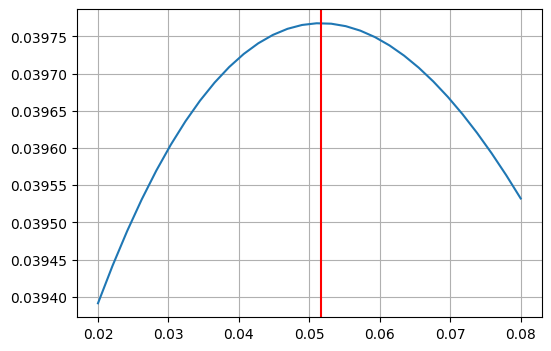

In [161]:
y_tx = np.linspace(0.02, 0.08, 30)

ptf_value = lambda y_t:  PV(cash_flows, y_t + s) + beta_hedge * PV(cash_flows, y_t)

portfolio_values = [ptf_value(y_t) for y_t in y_tx]

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(y_tx, portfolio_values)
ax.axvline(y-s, c='r')
ax.grid()